Scout site selection strategy

scout locations must first:

1. Be located within the uncovered area.
2. Be within developed or populated land.
3. Have reasonable access to a major road.
4. Be close to potential demand locations.
5. Be at least 3 km from existing stations.

Locations approximately 4–6 km from the nearest existing station will
be preferred. Locations farther away may still be considered when they
have strong demand and road accessibility.

After candidates are ranked, a minimum separation distance will be
applied so that the recommended stations serve different communities
rather than clustering in one area.

In [45]:
from pathlib import Path
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt 
import osmnx as ox
import folium as fl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [35]:
#defining paths
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"Processed"
figures_directory = project_root/"outputs"/"figures"
maps_directory = project_root/"outputs"/"maps"

maps_directory.mkdir(parents=True,exist_ok=True)
figures_directory.mkdir(parents=True,exist_ok=True)

In [ ]:
#load data
uncovered_area_file = (processed_data_directory/"preliminary_uncovered_area.gpkg")
station_file = (processed_data_directory/"verified_swap_station_points.geojson")

uncovered_area = gpd.read_file(uncovered_area_file)
stations = gpd.read_file(station_file)


In [4]:
stations_projected = stations.to_crs(uncovered_area.crs)

In [6]:
uncovered_area.crs == stations_projected.crs

True

In [7]:
#download developed land
boundary_file = (raw_data_directory/"greater_accra_boundary.geojson")
study_boundary = gpd.read_file(boundary_file)

In [8]:
study_boundary_wgs84 = study_boundary.to_crs("EPSG:4326")
query_polygon = study_boundary_wgs84.geometry.union_all()

In [14]:
print("Boundary records:", len(study_boundary_wgs84))
print("Boundary CRS:", study_boundary_wgs84.crs)
print("Boundary bounds:", study_boundary_wgs84.total_bounds)
print("Geometry empty:", study_boundary_wgs84.geometry.is_empty.any())
print("Geometry valid:", study_boundary_wgs84.geometry.is_valid.all())

if "display_name" in study_boundary_wgs84.columns:
    print(study_boundary_wgs84["display_name"])

Boundary records: 1
Boundary CRS: EPSG:4326
Boundary bounds: [-0.5197049  5.4706519  0.6722593  6.1076145]
Geometry empty: False
Geometry valid: True
0    Greater Accra Region, Ghana
Name: display_name, dtype: object


In [10]:
developed_land_tags = {"Landuse":["residental","commerical","retail","industrial"]}

In [15]:
ox.settings.use_cache = True
ox.settings.log_console = True

In [17]:
place_name = "Greater Accra Region, Ghana"
developed_land_tags = { "landuse": ["residential","commercial","retail","industrial",]}
developed_features = ox.features_from_place(place_name,tags=developed_land_tags,)
print("Downloaded features:", len(developed_features))

Downloaded features: 1671


In [19]:
developed_land = developed_features[developed_features.geometry.geom_type.isin(["Polygon","Multipolygon"])].copy()

columns_to_keep = [column for column in["landuse","name","geometry"] if column in developed_land.columns]
developed_land = (developed_land[columns_to_keep].reset_index(drop=True))
print("Developed_land polygons:",len(developed_land))

Developed_land polygons: 1659


In [20]:
developed_land_projected =developed_land.to_crs(uncovered_area.crs)
print("match:",developed_land_projected.crs == developed_land_projected.crs)

match: True


In [22]:
developed_geometry = (developed_land_projected.geometry.union_all())
uncovered_geometry = (uncovered_area.geometry.union_all())

In [23]:
developed_uncovered_geometry = (developed_geometry.intersection(uncovered_geometry))

developed_uncovered_area = gpd.GeoDataFrame(
    {"scout_filter":["Developed land outside existing 3km coverage"]}, 
    geometry=[developed_uncovered_geometry],crs=uncovered_area.crs
)

In [24]:
developed_uncovered_area_km2 = (developed_uncovered_geometry.area / 1_000_000)
print("Developed uncovered area:",round(developed_uncovered_area_km2,2))

Developed uncovered area: 1103.76


In [27]:
#saving filtered area 
developed_uncovered_file = (processed_data_directory/"developed_uncovered_area.gpkg")
developed_uncovered_area.to_file(developed_uncovered_file,driver="GPKG")
print("File saved:",developed_uncovered_file.exists())

File saved: True


In [28]:
#downloading major roads 
place_name = "Greater Accra Region, Ghana"

major_road_types = ["motorway","motorway_link","trunk","trunk_link","primary","primary_link","secondary","secondary_link","tertiary","tertiary_link"]
major_road_features = ox.features_from_place(place_name,tags={"highway":major_road_types},)
print("Downloaded road features:",len(major_road_types))

Downloaded road features: 10


In [29]:
major_roads =major_road_features[major_road_features.geometry.geom_type.isin(["LineString","MultilineString"])].copy()
roads_columns = [ column for column in ["highway","name","geometry"] if column in major_roads.columns]
major_roads = major_roads[roads_columns].reset_index(drop=True)

print("Major-road lines:",len(major_roads))
print(major_roads["highway"].value_counts())

Major-road lines: 5272
highway
tertiary          1924
secondary         1150
primary            779
trunk              618
trunk_link         280
primary_link       219
secondary_link     141
motorway_link       63
motorway            53
tertiary_link       45
Name: count, dtype: int64


In [30]:
major_roads_projected = major_roads.to_crs(developed_uncovered_area.crs)
print("matches:",major_roads_projected.crs == developed_uncovered_area.crs)

matches: True


In [31]:
road_access_distance_metres =750
road_access_geometry = (major_roads_projected.geometry.buffer(road_access_distance_metres).union_all())

In [32]:
developed_gap_geometry =(developed_uncovered_area.geometry.union_all())
road_access_geometry = (developed_gap_geometry.intersection(road_access_geometry))

road_accessible_scout_area = gpd.GeoDataFrame({"scout_filter":["Developed Uncovered Land near Major roads "]},geometry=[road_access_geometry],crs=developed_uncovered_area.crs,)

In [33]:
print( "Geometry empty:",road_accessible_scout_area .geometry.is_empty.any(),)
print("Geometry valid:",road_accessible_scout_area .geometry.is_valid.all(),)
road_accessible_area_km2 = (road_access_geometry.area / 1_000_000)
print("Road-accessible candidate area:",round(road_accessible_area_km2, 2),"km²",)

Geometry empty: False
Geometry valid: True
Road-accessible candidate area: 776.26 km²


In [34]:
road_accessible_file = ( processed_data_directory/ "road_accessible_developed_gaps.gpkg")

road_accessible_scout_area.to_file( road_accessible_file,driver="GPKG",)

print("File saved:", road_accessible_file.exists())

File saved: True


In [36]:
#downloading potential demand location

place_name = "Greater Accra Region, Ghana"

demand_tags = {"amenity":["marketplace","fuel","bus_station","university","college"],"shop":["mall","supermarket",],"public_transport":["station",],}

demand_features = ox.features_from_place(place_name,tags=demand_tags)
print(len(demand_tags))


3


In [37]:
required_columns = ["amenity","shop","public_transport","name",]

for column in required_columns:
    if column not in demand_features.columns:
        demand_features[column] = pd.NA
        
demand_locations = demand_features[["amenity","shop","public_transport","name","geometry"]].copy()

In [38]:
demand_locations_projected = demand_locations.to_crs(road_accessible_scout_area.crs)

demand_locations_projected["geometry"] = (demand_locations_projected.geometry.representative_point())

In [39]:
demand_locations_projected["demand_type"] = (demand_locations_projected["amenity"].fillna(demand_locations_projected["shop"])
.fillna(demand_locations_projected["public_transport"]))

demand_locations_projected.reset_index(drop=True,inplace=True)

In [41]:
demand_locations_projected

,amenity,shop,public_transport,name,geometry,demand_type
0,fuel,NaN,NaN,NaN,POINT (149181.007 615193.106),fuel
1,fuel,NaN,NaN,Total,POINT (147465.878 616094.611),fuel
2,fuel,NaN,NaN,Shell,POINT (147345.275 615340.525),fuel
3,fuel,NaN,NaN,Goil,POINT (147450.53 615764.13),fuel
4,NaN,supermarket,NaN,Koala Shopping Centre,POINT (147545.898 616174.568),supermarket
...,...,...,...,...,...,...
1258,fuel,NaN,NaN,NaN,POINT (133128.712 623520.657),fuel
1259,NaN,supermarket,NaN,NaN,POINT (170938.428 644695.436),supermarket
1260,university,NaN,NaN,Valley View University,POINT (154224.839 641673.044),university
1261,university,NaN,NaN,Valley View University,POINT (154224.839 641673.044),university


In [43]:
print("Demand locations:",len(demand_locations_projected),)
print("Geometry types:",demand_locations_projected.geometry.geom_type.unique(),)
print("CRS matches:",demand_locations_projected.crs == road_accessible_scout_area.crs)
print("\nDemand types:")
print(demand_locations_projected["demand_type"].value_counts())

Demand locations: 1263
Geometry types: ['Point']
CRS matches: True

Demand types:
demand_type
fuel              794
supermarket       153
bus_station       119
marketplace        60
college            53
university         40
mall               29
station            12
ferry_terminal      3
Name: count, dtype: int64


In [44]:
demand_locations_file = (processed_data_directory/"potential_demand_location.gpkg")

demand_locations_projected.to_file(demand_locations_file,driver="GPKG")
print("File saved:",demand_locations_file.exists())

File saved: True


In [46]:
demand_search_distance_metres = 3_000

scout_geometry = (road_accessible_scout_area.geometry.union_all())
demand_search_geometry = (scout_geometry.buffer(demand_search_distance_metres))
relevant_demand_locations = (demand_locations_projected[demand_locations_projected.geometry.intersects(demand_search_geometry)].copy().reset_index(drop=True))

print("All demand locations:",len(demand_locations_projected),)
print("Relevant demand locations:",len(relevant_demand_locations),)
print(relevant_demand_locations["demand_type"].value_counts())

All demand locations: 1263
Relevant demand locations: 1238
demand_type
fuel              785
supermarket       149
bus_station       115
marketplace        56
college            49
university         40
mall               29
station            12
ferry_terminal      3
Name: count, dtype: int64


In [47]:
relevant_demand_file = (processed_data_directory/ "relevant_demand_locations.gpkg")
relevant_demand_locations.to_file(relevant_demand_file,driver="GPKG",)

print("File saved:", relevant_demand_file.exists())

File saved: True


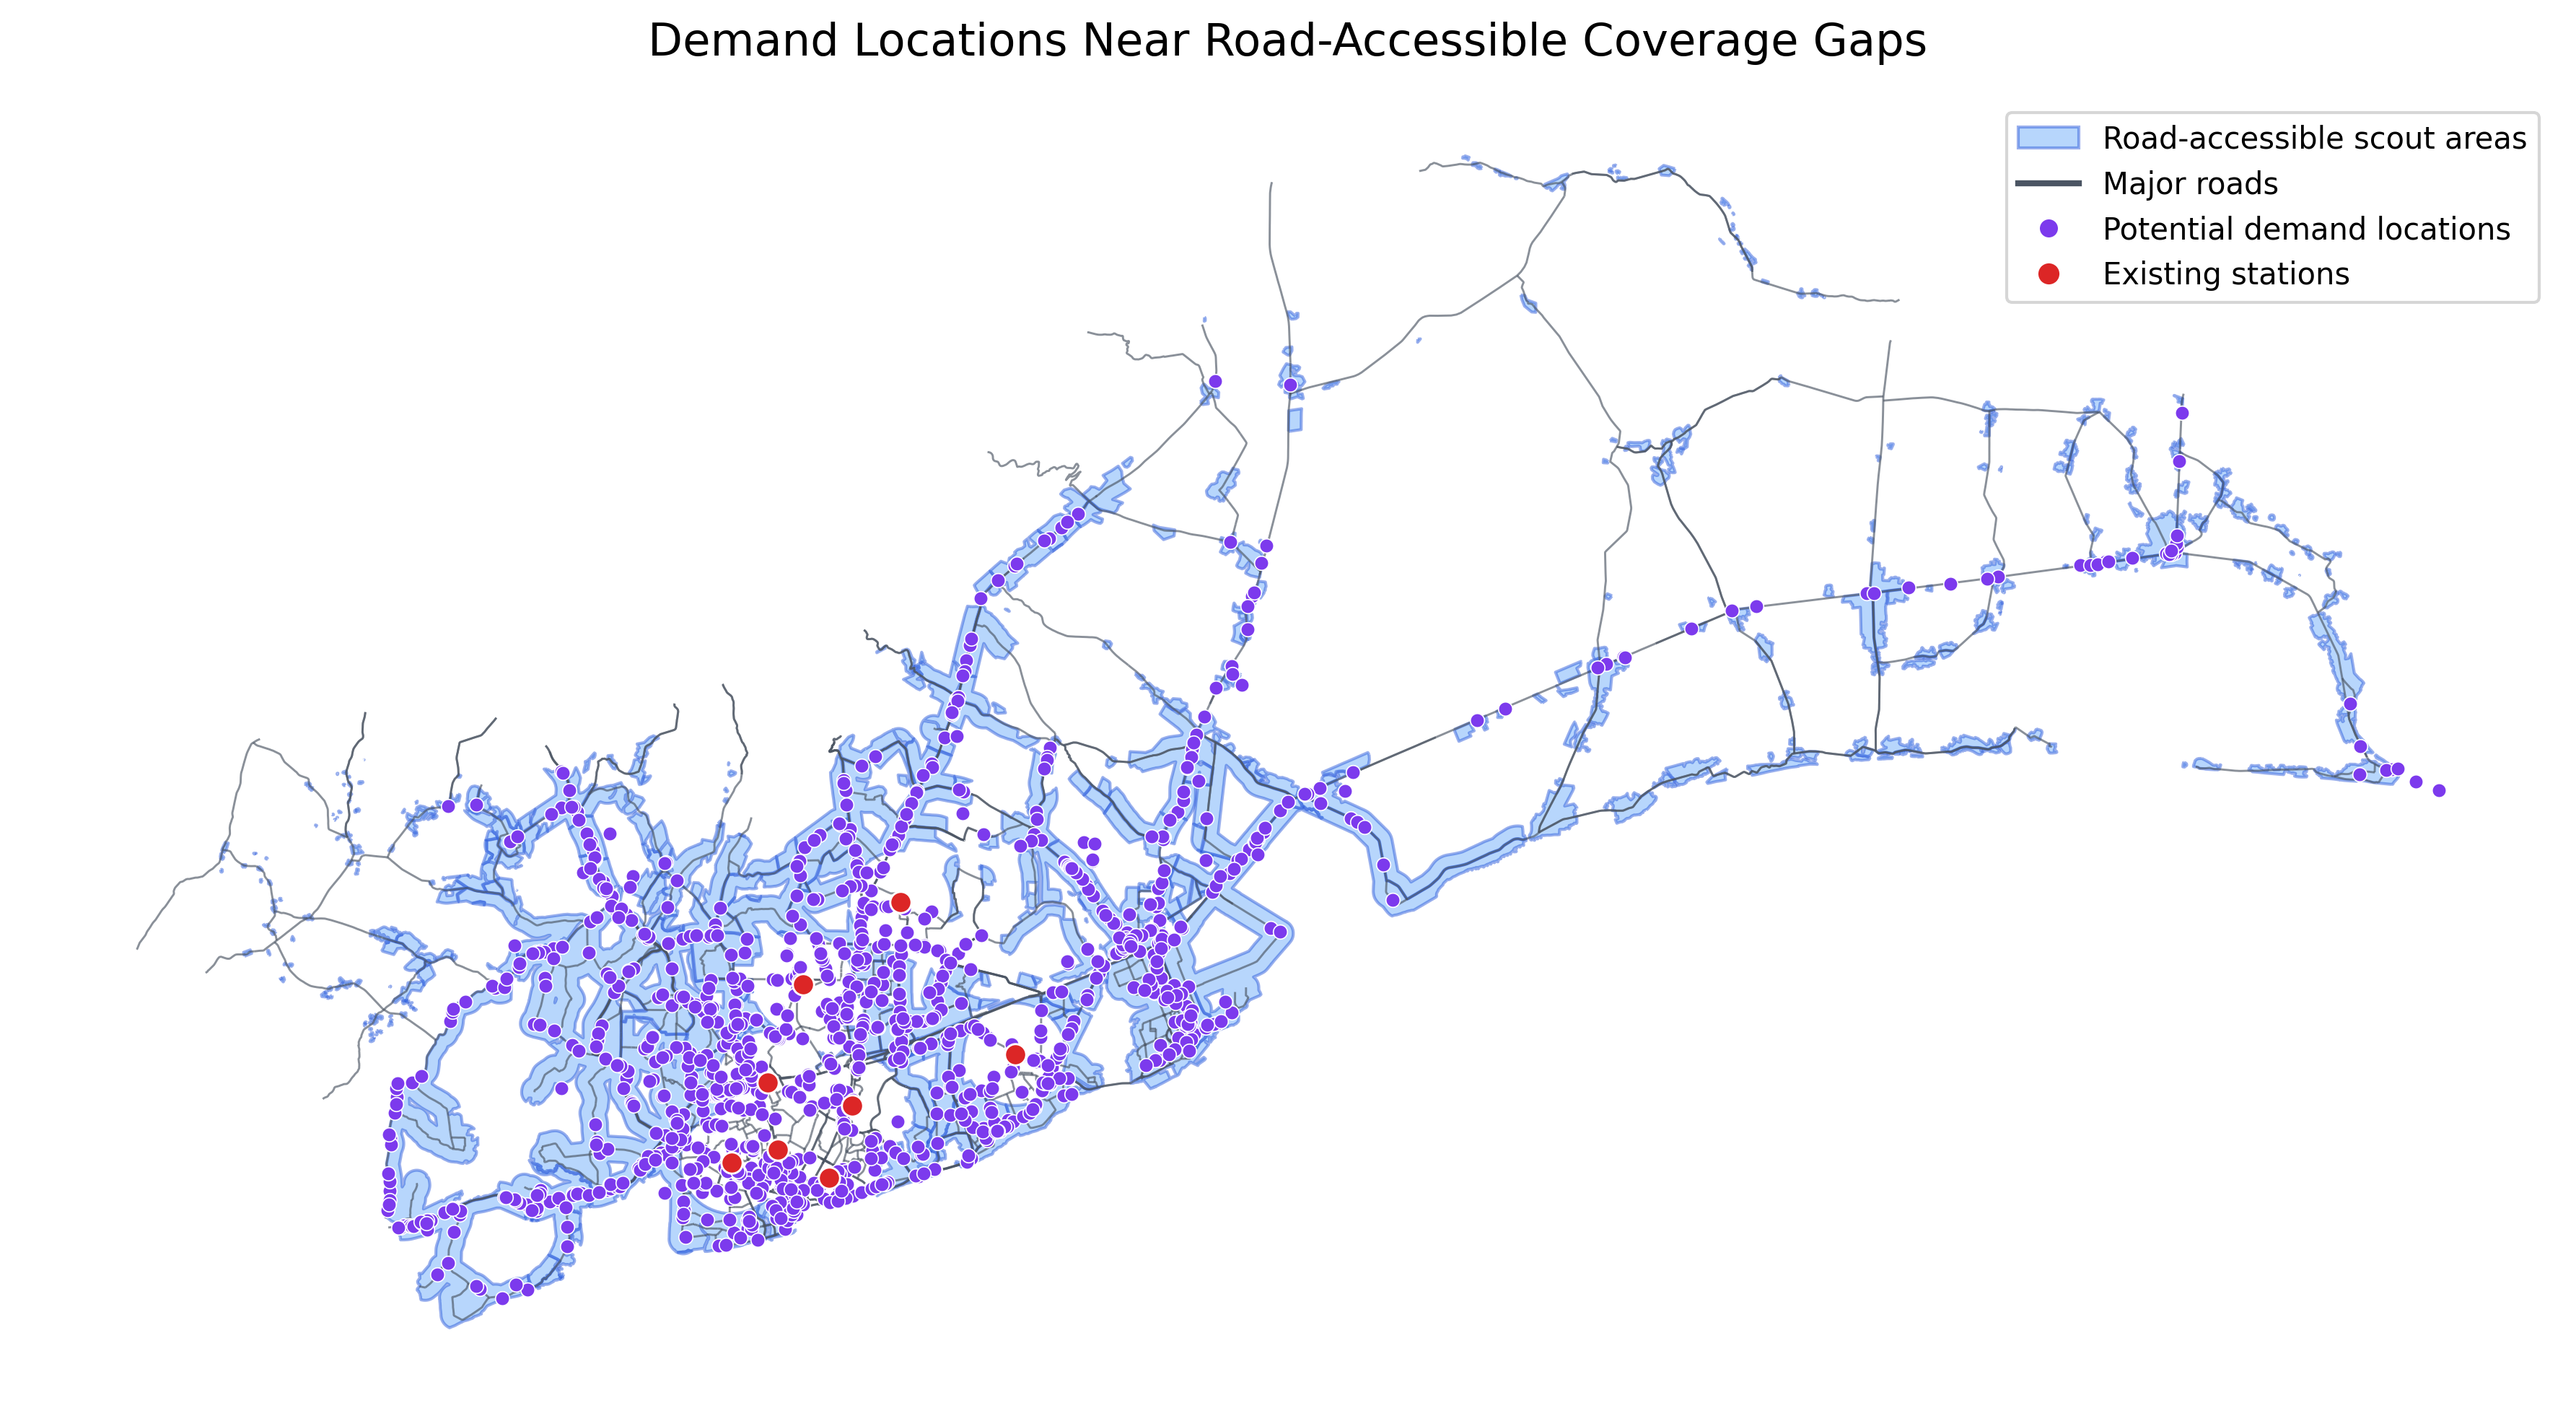

In [48]:
fig, ax = plt.subplots(figsize=(12, 9),dpi=300,)
road_accessible_scout_area.plot(ax=ax,facecolor="#60a5fa",edgecolor="#1d4ed8",alpha=0.45,linewidth=1,zorder=1,)

major_roads_projected.plot(ax=ax,color="#4b5563",linewidth=0.7,alpha=0.65,zorder=2,)
relevant_demand_locations.plot(ax=ax,color="#7c3aed",edgecolor="white",linewidth=0.4,markersize=22,zorder=3,)
stations_projected.plot(ax=ax,color="#dc2626",edgecolor="white",linewidth=0.7,markersize=50,zorder=4,)

legend_items = [Patch(facecolor="#60a5fa",edgecolor="#1d4ed8",alpha=0.45,label="Road-accessible scout areas",),
    Line2D([0],[0],color="#4b5563",linewidth=2,label="Major roads",),
    Line2D([0],[0],marker="o",linestyle="none",markerfacecolor="#7c3aed",markeredgecolor="white",markersize=7,label="Potential demand locations",),
    Line2D([0],[0],marker="o",linestyle="none",markerfacecolor="#dc2626",markeredgecolor="white",markersize=8,label="Existing stations",),]
ax.legend(handles=legend_items,loc="upper right",)
ax.set_title("Demand Locations Near Road-Accessible Coverage Gaps",fontsize=15,pad=14,)
ax.set_axis_off()
plt.tight_layout()